In [1]:
import sys
sys.path.append('..')
import xarray as xr
import pandas as pd
from scipy import constants
import numpy as np
import matplotlib.pyplot as plt
import calendar
import glob
from sklearn.linear_model import LinearRegression

import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

In [2]:
years = [2019, 2020, 2021, 2022, 2023, 2024]

### GC posterior old (incorrect)

In [3]:
all_xch4_posterior = []
for year in years:
    # set directory
    if year == 2019:
        dirname = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/posterior_run/OutputDir/'
    else:
        dirname = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/posterior_run/OutputDir/'

    # Open StateMet collection (monthly)
    met_ds = xr.open_mfdataset(dirname + f'GEOSChem.StateMet.{year}*')
    mol_dry_air = (met_ds["Met_AIRDEN"] * met_ds["Met_AIRVOL"])*1e3/28.96 # mol

    # Open BoundaryConditions collection (1st day of each month)
    # this is the same as SpeciesConc collection but with the first hour (t=0) outputted. 3-hour timesteps in each file
    BC_ds = xr.open_mfdataset(dirname+f"GEOSChem.BoundaryConditions.{year}*01_0000z.nc4")
    mol_ch4 = BC_ds['SpeciesBC_CH4'] * mol_dry_air

    # mean XCH4 excluding south of -60 latitude
    xch4 = 1e9 * (
        mol_ch4.sel(lat=mol_ch4["lat"] > -60).sum(dim="lev") / 
        mol_dry_air.sel(lat=mol_dry_air["lat"] > -60).sum(dim="lev")
    ).mean(dim=["lat", "lon"])

    xch4 = xch4.to_numpy()

    all_xch4_posterior.extend(xch4)

In [4]:
all_xch4 = np.array(all_xch4_posterior)
datetimes = pd.date_range(start=f"{years[0]}-01-01", end=f"{years[-1]}-12-01", freq="MS")

df_posterior = pd.DataFrame({"xch4": all_xch4}, index=datetimes)
df_posterior.index.name = "Month"

In [5]:
df_year_posterior = df_posterior.resample('YS').mean()
posterior_2019 = df_year_posterior.iloc[0,0]

df_year_posterior['percent_change'] = ((df_year_posterior['xch4'] - posterior_2019) / posterior_2019) * 100
df_year_posterior

,xch4,percent_change
Month,,
2019-01-01,1822.949585,0.000000
2020-01-01,1833.594238,0.583925
2021-01-01,1850.327637,1.501855
2022-01-01,1864.904663,2.301494
2023-01-01,1874.193726,2.811056
2024-01-01,1880.735840,3.169931


### GC posterior revised

In [3]:
def load_gc_posterior(years):
    gc_xch4_mean_all = []
    for year in years:
        if year == 2019:
            obs_file = f"/n/home12/mhe/lfs/Global_{year}_annual_ResMefix_2/data_posterior_extracted_fullyear/gc_ch4_posterior.npz"
            time_file = f"/n/home12/mhe/lfs/Global_{year}_annual_ResMefix_2/data_posterior_extracted_fullyear/time.npz"
        else:
            obs_file = f"/n/home12/mhe/lfs/Global_{year}_annual/data_posterior_extracted_fullyear/gc_ch4_posterior.npz"
            time_file = f"/n/home12/mhe/lfs/Global_{year}_annual/data_posterior_extracted_fullyear/time.npz"
        
        gc_xch4 = np.load(obs_file)['xch40']
        time = np.load(time_file)['time']
        time = pd.to_datetime(time, format='%Y%m%d')

        gc_xch4_mean = gc_xch4.mean()
        gc_xch4_mean_all.append(gc_xch4_mean)

    return pd.DataFrame({
        'Year': pd.to_datetime([f'{year}-01-01' for year in years]),
        'xch4': gc_xch4_mean_all,
    })

In [4]:
df_year_posterior = load_gc_posterior(years)
df_year_posterior.set_index('Year', inplace=True)
gc_posterior_2019 = df_year_posterior.iloc[0,0]

df_year_posterior['percent_change'] = ((df_year_posterior['xch4'] - gc_posterior_2019) / gc_posterior_2019) * 100
df_year_posterior['growth'] = df_year_posterior['xch4'].diff()

In [5]:
df_year_posterior

,xch4,percent_change,growth
Year,,,
2019-01-01,1836.017493,0.000000,NaN
2020-01-01,1850.320912,0.779046,14.303419
2021-01-01,1866.681258,1.670124,16.360346
2022-01-01,1878.794656,2.329889,12.113399
2023-01-01,1887.477143,2.802787,8.682487
2024-01-01,1894.975327,3.211180,7.498184


### NOAA data

In [6]:
ch4_noaa = pd.read_csv("../noaa_ch4_annmean_gl.csv", usecols=["year", "mean","unc"], index_col="year", parse_dates=True)
ch4_noaa.rename(columns={"mean": "ch4"}, inplace=True)

print(ch4_noaa)

                ch4   unc
year                     
2019-01-01  1866.58  0.55
2020-01-01  1878.72  0.59
2021-01-01  1894.72  0.53
2022-01-01  1910.92  0.75
2023-01-01  1921.61  0.46
2024-01-01  1929.97  0.58


In [7]:
ch4_noaa_2019 = ch4_noaa.iloc[0,0]

ch4_noaa['percent_change'] = ((ch4_noaa['ch4'] - ch4_noaa_2019) / ch4_noaa_2019) * 100

ch4_noaa

,ch4,unc,percent_change
year,,,
2019-01-01,1866.58,0.55,0.000000
2020-01-01,1878.72,0.59,0.650387
2021-01-01,1894.72,0.53,1.507570
2022-01-01,1910.92,0.75,2.375467
2023-01-01,1921.61,0.46,2.948173
2024-01-01,1929.97,0.58,3.396051


In [8]:
# get uncertainties in the growth rate
C0 = ch4_noaa.iloc[0]['ch4']
sigma0 = ch4_noaa.iloc[0]['unc']

ch4_noaa['diff_unc'] = np.sqrt(ch4_noaa['unc']**2 + sigma0**2)
ch4_noaa.loc[ch4_noaa.index[0], 'diff_unc'] = 0

# error propagation
# For a given year i, we have:
#   f(C_i, C_0) = 100 * ((C_i / C_0) - 1)
# with uncertainty:
#   sigma_f = 100 * sqrt((sigma_i / C0)**2 + ((C_i * sigma0)/(C0**2))**2)
# ch4_noaa.iloc[1:, ch4_noaa.columns.get_loc('unc_percent')] = 100 * np.sqrt(
#     (ch4_noaa.iloc[1:]['unc'] / C0)**2 + ((ch4_noaa.iloc[1:]['ch4'] * sigma0) / (C0**2))**2
# )

ch4_noaa['unc_percent'] = np.sqrt((ch4_noaa['diff_unc'] / C0)**2 + ((ch4_noaa['diff_unc'] * sigma0) / C0**2)**2) * 100

ch4_noaa

,ch4,unc,percent_change,diff_unc,unc_percent
year,,,,,
2019-01-01,1866.58,0.55,0.000000,0.000000,0.000000
2020-01-01,1878.72,0.59,0.650387,0.806598,0.043213
2021-01-01,1894.72,0.53,1.507570,0.763806,0.040920
2022-01-01,1910.92,0.75,2.375467,0.930054,0.049827
2023-01-01,1921.61,0.46,2.948173,0.717008,0.038413
2024-01-01,1929.97,0.58,3.396051,0.799312,0.042822


In [9]:
# get mean growth rate
slope, _ = np.polyfit(years, ch4_noaa['ch4'], 1)
base_2019 = ch4_noaa.iloc[0]['ch4']
print(f'slope: {slope:.2f} ppb/yr')
print(f'{slope / base_2019 * 100:.2f} %')

slope: 13.19 ppb/yr
0.71 %


### TROPOMI data

In [10]:
obs_2019 = np.load("/n/home12/mhe/lfs/Global_2019_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2019 = np.load("/n/home12/mhe/lfs/Global_2019_annual/data_converted_extracted_fullyear/time.npz")

obs_2020 = np.load("/n/home12/mhe/lfs/Global_2020_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2020 = np.load("/n/home12/mhe/lfs/Global_2020_annual/data_converted_extracted_fullyear/time.npz")

obs_2021 = np.load("/n/home12/mhe/lfs/Global_2021_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2021 = np.load("/n/home12/mhe/lfs/Global_2021_annual/data_converted_extracted_fullyear/time.npz")

obs_2022 = np.load("/n/home12/mhe/lfs/Global_2022_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2022 = np.load("/n/home12/mhe/lfs/Global_2022_annual/data_converted_extracted_fullyear/time.npz")

obs_2023 = np.load("/n/home12/mhe/lfs/Global_2023_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2023 = np.load("/n/home12/mhe/lfs/Global_2023_annual/data_converted_extracted_fullyear/time.npz")

obs_2024 = np.load("/n/home12/mhe/lfs/Global_2024_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2024 = np.load("/n/home12/mhe/lfs/Global_2024_annual/data_converted_extracted_fullyear/time.npz")

obs_2019_mean = obs_2019['y'].mean()
obs_2020_mean = obs_2020['y'].mean()
obs_2021_mean = obs_2021['y'].mean()
obs_2022_mean = obs_2022['y'].mean()
obs_2023_mean = obs_2023['y'].mean()
obs_2024_mean = obs_2024['y'].mean()

In [11]:
obs = [obs_2019_mean, obs_2020_mean, obs_2021_mean, obs_2022_mean, obs_2023_mean, obs_2024_mean]
df_tropomi = pd.DataFrame({
    'Year': pd.to_datetime([f'{year}-01-01' for year in years]),  # Create a datetime index
    'xch4': obs
})
df_tropomi.set_index('Year', inplace=True)
tropomi_2019 = df_tropomi.iloc[0,0]

df_tropomi['percent_change'] = ((df_tropomi['xch4'] - tropomi_2019) / tropomi_2019) * 100
df_tropomi['growth'] = df_tropomi['xch4'].diff()

In [12]:
df_tropomi

,xch4,percent_change,growth
Year,,,
2019-01-01,1834.536106,0.000000,NaN
2020-01-01,1850.826434,0.887981,16.290328
2021-01-01,1865.271017,1.675351,14.444583
2022-01-01,1878.349078,2.388232,13.078061
2023-01-01,1886.812103,2.849549,8.463026
2024-01-01,1895.293480,3.311866,8.481377


In [13]:
# get mean growth rate
slope, _ = np.polyfit(years, df_tropomi['xch4'], 1)
base_2019 = df_tropomi.iloc[0]['xch4']
print(f'slope: {slope:.2f} ppb/yr')
print(f'{slope / base_2019 * 100:.2f} %')

slope: 12.14 ppb/yr
0.66 %


In [14]:
# growth rate
X = np.array(years).reshape(-1, 1)
y = np.array(obs).reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
slope = model.coef_[0][0]
print(f"slope: {slope} ppb/yr")

# 2019-2021
X = np.array(years[0:3]).reshape(-1, 1)
y = np.array(obs[0:3]).reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
slope_2019_2021 = model.coef_[0][0]
print(f"2019-2021 slope: {slope_2019_2021} ppb/yr")

# 2022-2024
X = np.array(years[3:]).reshape(-1, 1)
y = np.array(obs[3:]).reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
slope_2022_2024 = model.coef_[0][0]
print(f"2022-2024 slope: {slope_2022_2024} ppb/yr")

slope: 12.137769682608425 ppb/yr
2019-2021 slope: 15.367455618410865 ppb/yr
2022-2024 slope: 8.472201060327277 ppb/yr


### Plot

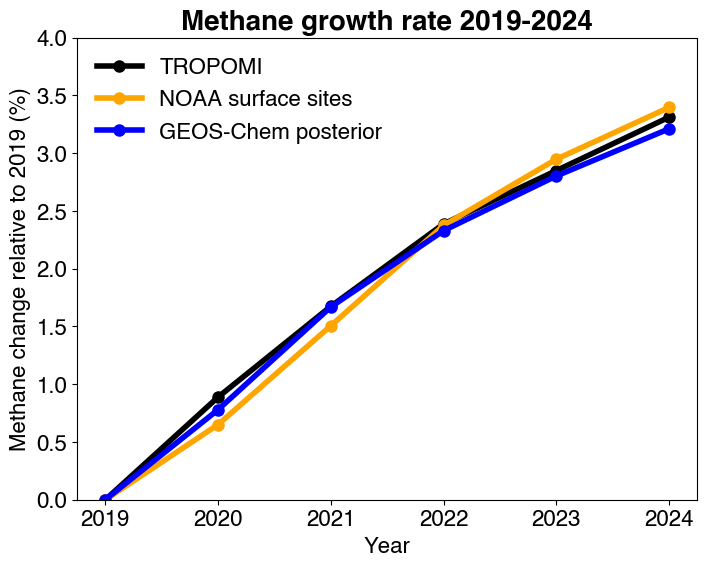

In [16]:
fig = plt.figure(figsize=(8, 6))
plt.rcParams.update({"font.size": 16})

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

# plt.plot(df_year_prior['percent_change'],linewidth=4,c='blue',linestyle="--",label='GEOS-Chem prior')
plt.plot(df_tropomi['percent_change'],linewidth=4,color='black',marker='o',markersize='8',label='TROPOMI')
plt.plot(ch4_noaa['percent_change'],linewidth=4,c='orange',marker='o',markersize='8',label='NOAA surface sites')
# plt.errorbar(ch4_noaa.index, ch4_noaa['percent_change'], yerr=ch4_noaa['unc_percent'], fmt='o', color='orange', markersize=8, capsize=5)
plt.plot(df_year_posterior['percent_change'],linewidth=4,c='blue',marker='o',markersize='8',label='GEOS-Chem posterior')
plt.xticks(df_year_posterior.index, df_year_posterior.index.year)
plt.ylim(0,4)
plt.xlabel('Year')
plt.ylabel('Methane change relative to 2019 (%)')
plt.title('Methane growth rate 2019-2024', fontproperties=title_font, fontsize=20)
plt.legend(frameon=False, loc='upper left')
plt.show()

In [17]:
# steady state calculation for 2019
m_0_2019 = 5128.9
E_0_2019 = 570.6
k_2019 = 0.09120864
L_0_2019 = 75.043
t_2019 = np.arange(0,6)

# 2020
m_0_2020 = 5158.7
E_0_2020 = 579.2
k_2020 = 0.0909338
L_0_2020 = 75.043
t_2020 = np.arange(0,5)

# 2021
m_0_2021 = 5206.61
E_0_2021 = 601.4
k_2021 = 0.0896937
L_0_2021 = 75.043
t_2021 = np.arange(0,4)

# 2022
m_0_2022 = 5249
E_0_2022 = 573.3
k_2022 = 0.08929
L_0_2022 = 75.043
t_2022 = np.arange(0,3)

def steady_state(m_0, E_0, k, L_0, t):
    m_t = m_0 * np.exp(-k*t) + (E_0 - L_0)/k*(1 - np.exp(-k*t))
    ss = (m_t - m_0) / m_0 * 100
    return ss

In [18]:
ss_2019 = steady_state(m_0_2019, E_0_2019, k_2019, L_0_2019, t_2019)

ss_2020 = steady_state(m_0_2020, E_0_2020, k_2020, L_0_2020, t_2020)
ss_2020 += df_year_posterior['percent_change'].iloc[1]

ss_2021 = steady_state(m_0_2021, E_0_2021, k_2021, L_0_2021, t_2021)
ss_2021 += df_year_posterior['percent_change'].iloc[2]

ss_2022 = steady_state(m_0_2022, E_0_2022, k_2022, L_0_2022, t_2022)
ss_2022 += df_year_posterior['percent_change'].iloc[3]

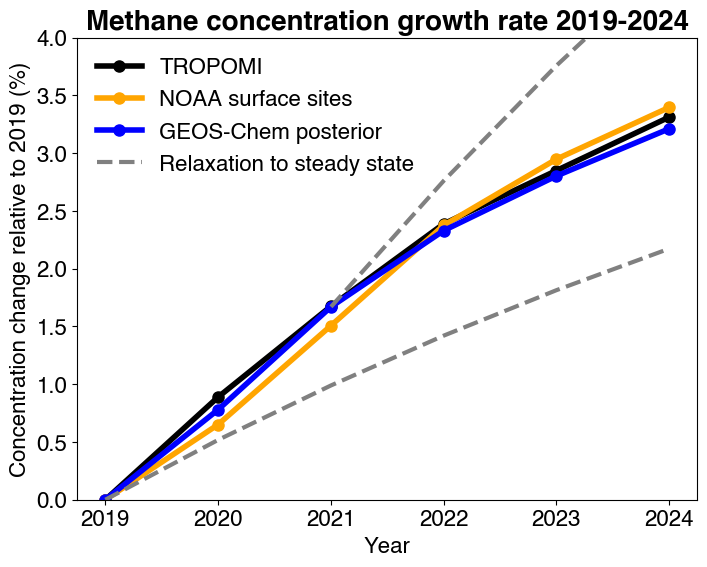

In [19]:
fig = plt.figure(figsize=(8, 6))
plt.rcParams.update({"font.size": 16})

# plt.plot(df_year_prior['percent_change'],linewidth=4,c='blue',linestyle="--",label='GEOS-Chem prior')
plt.plot(df_tropomi['percent_change'],linewidth=4,color='black',marker='o',markersize='8',label='TROPOMI')
plt.plot(ch4_noaa['percent_change'],linewidth=4,c='orange',marker='o',markersize='8',label='NOAA surface sites')
# plt.errorbar(ch4_noaa.index, ch4_noaa['percent_change'], yerr=ch4_noaa['unc_percent'], fmt='o', color='orange', markersize=8, capsize=5)
plt.plot(df_year_posterior['percent_change'],linewidth=4,c='blue',marker='o',markersize='8',label='GEOS-Chem posterior')
plt.plot(df_year_posterior.index, ss_2019, linewidth=3, c='grey', linestyle='dashed', label='Relaxation to steady state')
plt.plot(df_year_posterior.index[2:], ss_2021, linewidth=3, c='grey', linestyle='dashed')
plt.xticks(df_year_posterior.index, df_year_posterior.index.year)
plt.ylim(0,4)
plt.xlabel('Year')
plt.ylabel('Concentration change relative to 2019 (%)')
plt.title('Methane concentration growth rate 2019-2024', fontproperties=title_font, fontsize=20)
plt.legend(frameon=False, loc='upper left', fontsize=16)
plt.savefig('figures/Fig1_revised.png', dpi=1200, bbox_inches='tight')
plt.show()

In [19]:
# how much higher is posterior growth rate than steady state?
diff = (df_year_posterior['percent_change'] - ss_2019)/ss_2019 * 100
print(diff.mean())

57.15121525019053
